# Pima-Indians-Diabetes

In this project, I use a machine learning models to predict diabetes based on features.

In [3]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import seaborn as sns 

**Undrstand the dataset and cheeck null value and duplcate value**

In [6]:
df = pd.read_csv(r"C:\Users\Hanan\Desktop\git hup -project\data_set\diabetes.csv")

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
sns.countplot(x='Pregnancies', hue='Outcome', data=df)
plt.title('Diabetes Outcome by Number of Pregnancies')

**Check the Outlier**

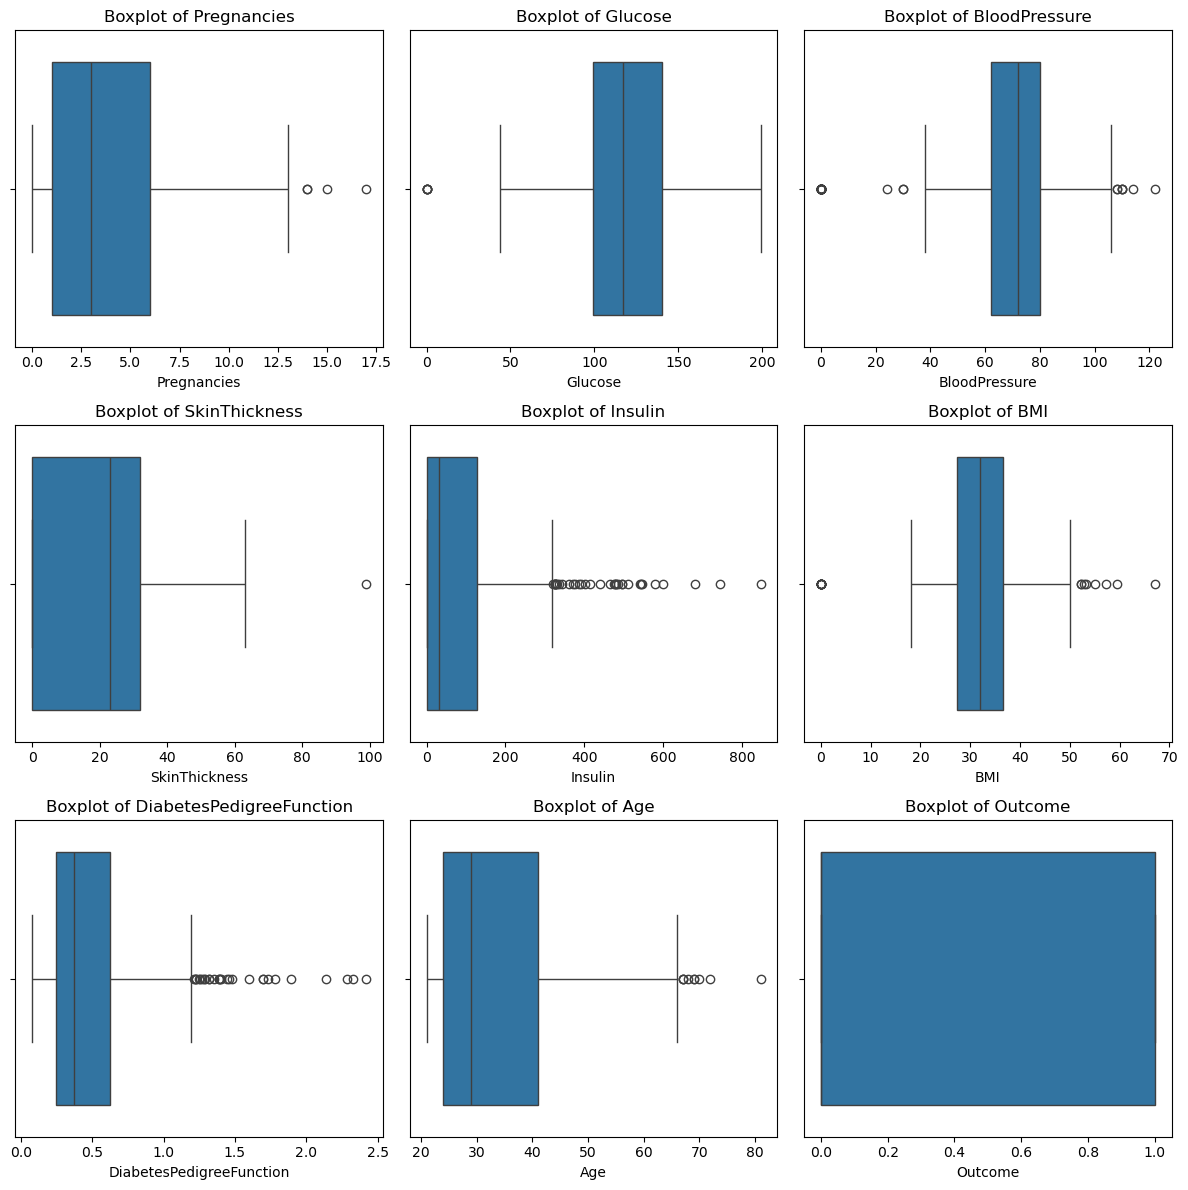

In [17]:
plt.figure(figsize=(12,12))

# Loop through columns with correct colon and indentation
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(f'Boxplot of {col}')  # Added for clear labels

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

In [19]:
df_clean = df.copy()

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'] 
for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]



In [21]:
df2 = df_clean

In [23]:
df2.duplicated().sum()

0

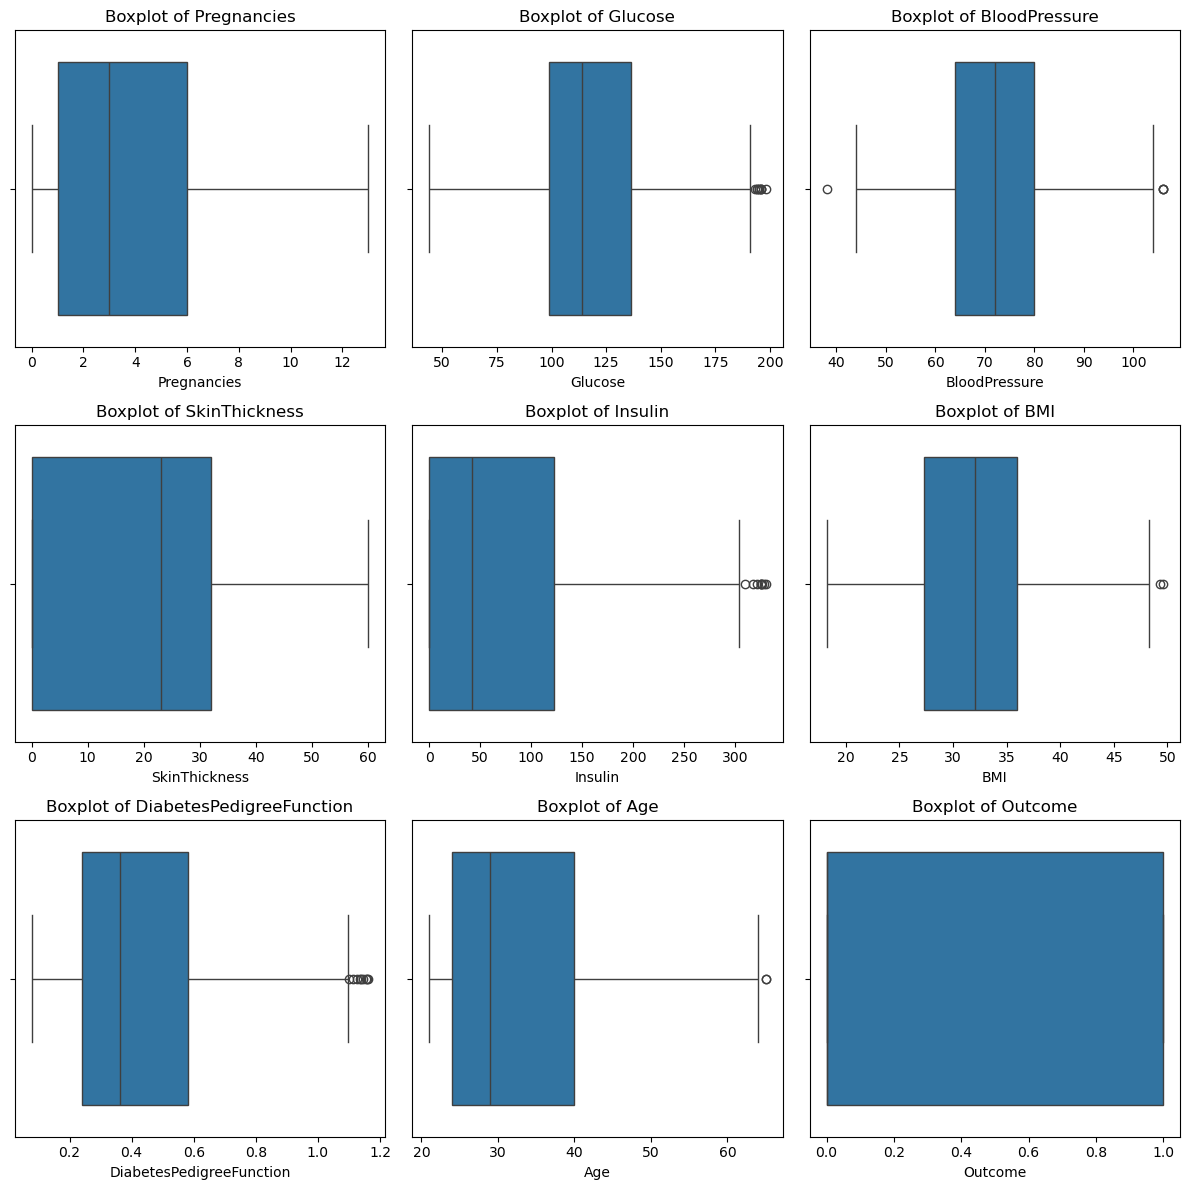

In [25]:
plt.figure(figsize=(12,12))

# Loop through columns with correct colon and indentation
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=col, data=df2)
    plt.title(f'Boxplot of {col}')  # Added for clear labels

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

In [27]:
df2.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,3.786164,118.869497,72.007862,20.745283,69.017296,31.964151,0.426237,32.555031,0.309748
std,3.251388,28.996773,11.301102,15.231688,83.601857,6.384132,0.245088,10.879807,0.462754
min,0.000000,44.000000,38.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.300000,0.238750,24.000000,0.000000
50%,3.000000,114.000000,72.000000,23.000000,42.500000,32.000000,0.361000,29.000000,0.000000
75%,6.000000,136.250000,80.000000,32.000000,122.000000,36.000000,0.583000,40.000000,1.000000
max,13.000000,198.000000,106.000000,60.000000,330.000000,49.600000,1.162000,65.000000,1.000000


In [29]:
print("SkinThickness =", (df2['SkinThickness'] == 0).sum())
print("Insulin =", (df2['Insulin'] == 0).sum())

SkinThickness = 173
Insulin = 300


In [ ]:
import numpy as np

df2['SkinThickness'] = df2['SkinThickness'].replace(0, np.nan)
df2['Insulin'] = df2['Insulin'].replace(0, np.nan)

df2['SkinThickness'].fillna(df2['SkinThickness'].median(), inplace=True)
df2['Insulin'].fillna(df2['Insulin'].median(), inplace=True)

In [31]:
import numpy as np

from sklearn.impute import KNNImputer
df2['SkinThickness'] = df2['SkinThickness'].replace(0, np.nan)
df2['Insulin'] = df2['Insulin'].replace(0, np.nan)


imputer = KNNImputer(n_neighbors=5)

df3 = pd.DataFrame(imputer.fit_transform(df2), columns=df2.columns)

In [33]:
df3.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,3.786164,118.869497,72.007862,28.466981,130.377044,31.964151,0.426237,32.555031,0.309748
std,3.251388,28.996773,11.301102,8.919199,60.592084,6.384132,0.245088,10.879807,0.462754
min,0.000000,44.000000,38.000000,7.000000,15.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,85.650000,27.300000,0.238750,24.000000,0.000000
50%,3.000000,114.000000,72.000000,28.900000,126.800000,32.000000,0.361000,29.000000,0.000000
75%,6.000000,136.250000,80.000000,34.000000,165.000000,36.000000,0.583000,40.000000,1.000000
max,13.000000,198.000000,106.000000,60.000000,330.000000,49.600000,1.162000,65.000000,1.000000


<Axes: xlabel='Outcome', ylabel='count'>

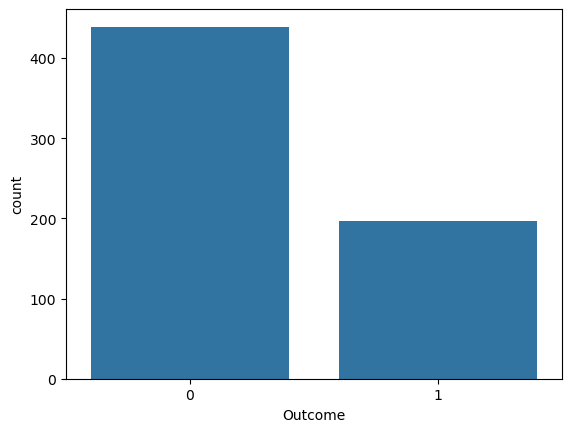

In [35]:
sns.countplot(x = df2['Outcome'])

from the pic above we can see the data set is unblance 

**Corrleation**

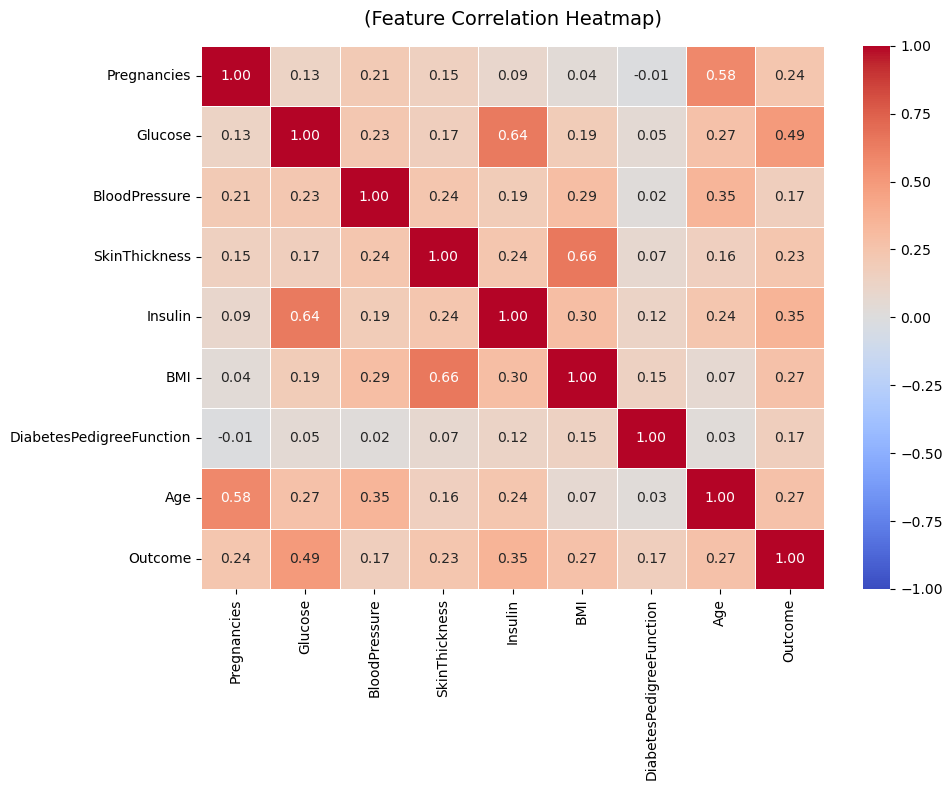

In [38]:
corr_matrix = df3.corr()

plt.figure(figsize=(10, 8)) 

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',   
    fmt=".2f",           
    linewidths=0.5,     
    vmin=-1, vmax=1      )

plt.title('(Feature Correlation Heatmap)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

From the picture above, the outcome has 
positive correlation with glucose 0.49 , insulin (0.35), age and BMI (0.27), pregnancies (0.24), and skin thickness (0.23) 
BloodPressure, ,DiabetesPedigreeFunction  0.17
In the first model, I will exclude BloodPressure and DiabetesPedigreeFunction to see whether they have different effects. because to have a little positive effect 

**split dataset**

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

X = df3[['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']]
Y = df3['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit على train فقط
X_test_scaled  = scaler.transform(X_test)        # transform على test

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

**Build the model (Random Forest)**

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Random Forest
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None  # 
)

model.fit(X_train_balanced, y_train_balanced)

# Evaluation
y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[70 18]
 [13 27]]
              precision    recall  f1-score   support

         0.0       0.84      0.80      0.82        88
         1.0       0.60      0.68      0.64        40

    accuracy                           0.76       128
   macro avg       0.72      0.74      0.73       128
weighted avg       0.77      0.76      0.76       128



In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# X و y
X = df3[['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age' , 'DiabetesPedigreeFunction' ,'BloodPressure']]
y = df3['Outcome']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (fit على train فقط)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Balance (SMOTE على train فقط)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Random Forest
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None  # خليها None لأنك موازنته بـ SMOTE
)

model.fit(X_train_balanced, y_train_balanced)

# Evaluation
y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[69 19]
 [10 30]]
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.83        88
         1.0       0.61      0.75      0.67        40

    accuracy                           0.77       128
   macro avg       0.74      0.77      0.75       128
weighted avg       0.79      0.77      0.78       128



From the results, we can observe the effect of adding DiabetesPedigreeFunction and BloodPressure back to the dataset. Their inclusion improved the model's performance, with accuracy increasing from 0.76 to 0.77, precision from 0.60 to 0.61, recall from 0.68 to 0.75, and F1-score from 0.64 to 0.67. The improvement in recall is particularly important for diabetes prediction, as it indicates that the model is able to identify a higher proportion of diabetic patients correctly. Therefore, despite their relatively weak correlation with the target variable, these features contribute useful information that enhances the overall classification performance.

In [76]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

# XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Training
model.fit(X_train_balanced, y_train_balanced)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[71 17]
 [14 26]]
              precision    recall  f1-score   support

         0.0       0.84      0.81      0.82        88
         1.0       0.60      0.65      0.63        40

    accuracy                           0.76       128
   macro avg       0.72      0.73      0.72       128
weighted avg       0.76      0.76      0.76       128



the results indicate that Random Forest outperformed XGBoost on all evaluation metrics. Random Forest achieved an accuracy of 0.77, precision of 0.61, recall of 0.75, and F1-score of 0.67, while XGBoost achieved an accuracy of 0.76, precision of 0.60, recall of 0.65, and F1-score of 0.63. 
Therefore, Random Forest was considered the better model for diabetes classification.